# Sampling in a particle filter

**Mohammed - GSR/5161/16**

The code behind the report: the world, the filter, the four resampling schemes, and the rules for
when to resample.

## The world

A robot drives 30 steps through a 10 m square with four landmarks. Positions wrap at the edges. At
each step it is given a control and then measures range and bearing to every landmark. Both the
motion and the measurements are noisy.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

SIZE      = np.array([10.0, 10.0])
LANDMARKS = np.array([[2.0, 2.0], [2.0, 8.0], [9.0, 2.0], [8.0, 9.0]])
START     = np.array([7.5, 2.0, np.pi / 2])
STEPS     = 30
CONTROL   = (0.25, 0.02)          # forward (m), turn (rad) per step
TRUE_MOTION      = (0.005, 0.002)  # the world's own noise
TRUE_MEASUREMENT = (0.2, 0.05)


def wrap(angle):
    return (np.asarray(angle) + np.pi) % (2 * np.pi) - np.pi


def validate(poses):
    poses = poses.copy()
    poses[:, 0] %= SIZE[0]
    poses[:, 1] %= SIZE[1]
    poses[:, 2] = wrap(poses[:, 2])
    return poses


def simulate(seed):
    """Drive the robot and record what it was told and what it saw."""
    rng = np.random.default_rng(seed)
    pose = START.copy()
    poses, measurements = [], []
    for _ in range(STEPS):
        pose[2] += CONTROL[1] + rng.normal(0, TRUE_MOTION[1])
        distance = CONTROL[0] + rng.normal(0, TRUE_MOTION[0])
        pose[0] += distance * np.cos(pose[2])
        pose[1] += distance * np.sin(pose[2])
        pose = validate(pose[None])[0]
        dx, dy = pose[0] - LANDMARKS[:, 0], pose[1] - LANDMARKS[:, 1]
        z = np.stack([np.hypot(dx, dy) + rng.normal(0, TRUE_MEASUREMENT[0], len(LANDMARKS)),
                      np.arctan2(dy, dx) + rng.normal(0, TRUE_MEASUREMENT[1], len(LANDMARKS))], axis=-1)
        poses.append(pose.copy())
        measurements.append(z)
    return np.array(poses), np.array(measurements)


true_poses, measurements = simulate(0)
print("true poses:", true_poses.shape, " measurements:", measurements.shape)

true poses: (30, 3)  measurements: (30, 4, 2)


## The model the filter assumes

Two conditional distributions. The motion model turns the control into a new pose, with noise. The
measurement model says how likely a reading is from a given pose.

Note the `- n_landmarks * (log std).sum()` term in the likelihood: it is the normalizing constant of
the Gaussian. It cancels when the weights are normalized, so it does not matter for filtering, but it
is exactly what the learning experiment needs, because it is the term that penalizes assuming too
much noise.

In [2]:
def propagate(poses, control, motion_std, rng):
    """p(x_t | x_{t-1}, u_t): turn, then move forward along the new heading."""
    poses = poses.copy()
    n = len(poses)
    poses[:, 2] += control[1] + rng.normal(0, motion_std[1], n)
    distance = control[0] + rng.normal(0, motion_std[0], n)
    poses[:, 0] += distance * np.cos(poses[:, 2])
    poses[:, 1] += distance * np.sin(poses[:, 2])
    return validate(poses)


def log_likelihood(poses, z, measurement_std):
    """log p(z | x) for every pose, as a proper density."""
    dx = poses[:, None, 0] - LANDMARKS[None, :, 0]
    dy = poses[:, None, 1] - LANDMARKS[None, :, 1]
    expected = np.stack([np.hypot(dx, dy), np.arctan2(dy, dx)], axis=-1)
    residual = expected - z[None]
    residual[..., 1] = wrap(residual[..., 1])
    std = np.asarray(measurement_std)
    normalizer = len(LANDMARKS) * (np.log(std).sum() + np.log(2 * np.pi))
    return -0.5 * np.sum((residual / std) ** 2, axis=(1, 2)) - normalizer

## The four resampling schemes

Each draws $N$ new particles from the weights. All four are unbiased -- a particle of weight $w^{(i)}$
is expected to be copied $Nw^{(i)}$ times -- and they differ only in how much that count varies, which
decides how many distinct particles survive.

In [3]:
def multinomial(weights, rng):
    """N independent draws. Largest variance of the four."""
    return np.searchsorted(np.cumsum(weights), rng.random(len(weights)))


def residual(weights, rng):
    """Whole part taken outright, the remainder drawn multinomially."""
    n = len(weights)
    copies = np.floor(n * weights).astype(int)
    indices = np.repeat(np.arange(n), copies)
    left = n - len(indices)
    if left:
        remainder = n * weights - copies
        remainder = remainder / remainder.sum()
        indices = np.concatenate([indices, np.searchsorted(np.cumsum(remainder), rng.random(left))])
    return indices


def stratified(weights, rng):
    """One draw inside each of N equal strata."""
    n = len(weights)
    positions = (np.arange(n) + rng.random(n)) / n
    return np.searchsorted(np.cumsum(weights), positions)


def systematic(weights, rng):
    """One random number, then even steps of 1/N. Lowest variance."""
    n = len(weights)
    positions = (np.arange(n) + rng.random()) / n
    return np.searchsorted(np.cumsum(weights), positions)


SCHEMES = {"multinomial": multinomial, "residual": residual,
           "stratified": stratified, "systematic": systematic}

Drawing all four from the same weights shows the difference directly: the ticks go from clumped
to evenly spaced, and a particle is copied once for every tick that lands on it.

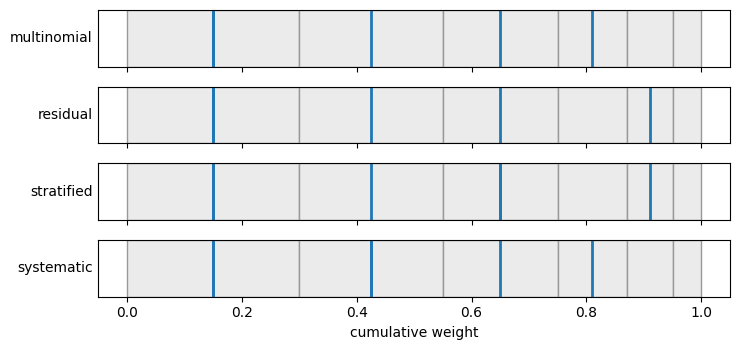

In [4]:
demo_w = np.array([0.30, 0.25, 0.20, 0.12, 0.08, 0.05])
rng = np.random.default_rng(3)
edges = np.concatenate([[0], np.cumsum(demo_w)])

fig, axes = plt.subplots(4, 1, figsize=(7.5, 3.6), sharex=True)
for ax, (name, fn) in zip(axes, SCHEMES.items()):
    for a, b in zip(edges[:-1], edges[1:]):
        ax.axvspan(a, b, color="0.92", ec="0.6")
    picks = fn(demo_w, np.random.default_rng(3))
    for p in picks:
        centre = (edges[p] + edges[p + 1]) / 2
        ax.axvline(centre, lw=2)
    ax.set_yticks([]); ax.set_ylabel(name, rotation=0, ha="right", va="center")
axes[-1].set_xlabel("cumulative weight")
fig.tight_layout()
plt.show()

## When to resample

Resampling fights degeneracy but discards particles, so a rule decides when it is worth it. The
effective sample size $\mathrm{ESS} = 1/\sum_i (w^{(i)})^2$ measures how far the weights have
collapsed.

In [5]:
def ess(weights):
    return 1.0 / np.sum(weights ** 2)


TRIGGERS = {
    "every step":        lambda w: True,
    "never":             lambda w: False,
    "ESS < 0.2 N":       lambda w: ess(w) < 0.2 * len(w),
    "ESS < 0.5 N":       lambda w: ess(w) < 0.5 * len(w),
    "ESS < 0.8 N":       lambda w: ess(w) < 0.8 * len(w),
    "max weight > 0.1":  lambda w: w.max() > 0.1,
    "max weight > 0.2":  lambda w: w.max() > 0.2,
    "max weight > 0.5":  lambda w: w.max() > 0.5,
}

## The filter

One step: propose from the motion model, weight by the measurement likelihood, normalize, and
resample if the rule says so. The sum of the unnormalized weights, kept on line `evidence`, is the
marginal likelihood of that step -- the quantity the learning experiment maximizes.

RMSE 0.147 m   mean ESS/N 0.69   distinct/N 0.71


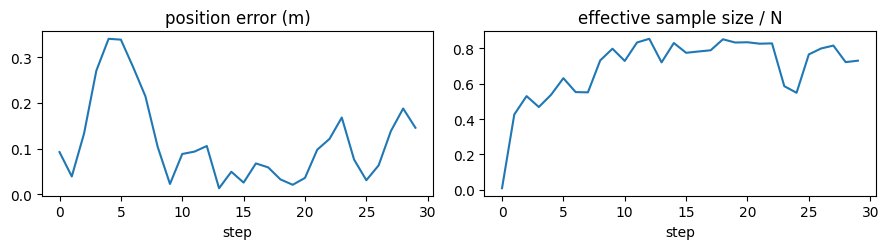

In [6]:
def particle_filter(true_poses, measurements, n_particles, scheme="systematic",
                    trigger="every step", motion_std=(0.1, 0.2), measurement_std=(0.4, 0.3),
                    start="uniform", seed=0):
    rng = np.random.default_rng(seed)
    if start == "uniform":
        poses = validate(np.column_stack([rng.uniform(0, SIZE[0], n_particles),
                                          rng.uniform(0, SIZE[1], n_particles),
                                          rng.uniform(0, 2 * np.pi, n_particles)]))
    else:
        poses = validate(START + rng.normal(0, 0.2, (n_particles, 3)))
    weights = np.full(n_particles, 1.0 / n_particles)

    errors, ess_trace, distinct, log_evidence = [], [], [], 0.0
    for z, truth in zip(measurements, true_poses):
        poses = propagate(poses, CONTROL, motion_std, rng)
        with np.errstate(divide="ignore"):      # a particle may carry zero weight
            log_w = np.log(weights) + log_likelihood(poses, z, measurement_std)

        top = log_w.max()                                  # the step's marginal likelihood
        log_evidence += top + np.log(np.exp(log_w - top).sum())

        weights = np.exp(log_w - top)
        weights /= weights.sum()
        ess_trace.append(ess(weights) / n_particles)

        if TRIGGERS[trigger](weights):
            picked = SCHEMES[scheme](weights, rng)
            poses, weights = poses[picked].copy(), np.full(n_particles, 1.0 / n_particles)
            distinct.append(len(np.unique(picked)) / n_particles)

        estimate = np.array([weights @ poses[:, 0], weights @ poses[:, 1],
                             np.arctan2(weights @ np.sin(poses[:, 2]), weights @ np.cos(poses[:, 2]))])
        errors.append(np.hypot(*(estimate[:2] - truth[:2])))

    return {"rmse": float(np.sqrt(np.mean(np.square(errors)))),
            "ess": float(np.mean(ess_trace)),
            "distinct": float(np.mean(distinct)) if distinct else 1.0,
            "log_likelihood": float(log_evidence),
            "errors": np.array(errors), "ess_trace": np.array(ess_trace)}


run = particle_filter(true_poses, measurements, 500, seed=0)
print(f"RMSE {run['rmse']:.3f} m   mean ESS/N {run['ess']:.2f}   distinct/N {run['distinct']:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 2.6))
ax[0].plot(run["errors"]);    ax[0].set_title("position error (m)")
ax[1].plot(run["ess_trace"]); ax[1].set_title("effective sample size / N")
for a in ax:
    a.set_xlabel("step")
fig.tight_layout()
plt.show()

## Experiment 1: does the resampling scheme matter?

Four schemes, everything else fixed, the same worlds and seeds for each.

In [7]:
SEEDS = range(8)
worlds = [simulate(s) for s in SEEDS]

print(f"{'scheme':<13}{'RMSE (m)':>10}{'distinct/N':>13}")
for name in SCHEMES:
    runs = [particle_filter(*w, 500, scheme=name, seed=s) for s, w in zip(SEEDS, worlds)]
    print(f"{name:<13}{np.mean([r['rmse'] for r in runs]):>10.3f}"
          f"{np.mean([r['distinct'] for r in runs]):>13.2f}")

scheme         RMSE (m)   distinct/N
multinomial       0.192         0.53
residual          0.183         0.64


stratified        0.243         0.64
systematic        0.194         0.70


The errors sit within the seed-to-seed spread of one another, while the number of distinct
particles surviving a resampling step separates the schemes cleanly, in the order their variance
predicts. That is the first finding: **the scheme changes diversity, not accuracy.**

## Experiment 2: when to resample?

In [8]:
print(f"{'rule':<19}{'RMSE (m)':>10}{'ESS/N':>9}{'distinct/N':>13}")
for name in TRIGGERS:
    runs = [particle_filter(*w, 500, trigger=name, seed=s) for s, w in zip(SEEDS, worlds)]
    print(f"{name:<19}{np.mean([r['rmse'] for r in runs]):>10.3f}"
          f"{np.mean([r['ess'] for r in runs]):>9.3f}"
          f"{np.mean([r['distinct'] for r in runs]):>13.2f}")

rule                 RMSE (m)    ESS/N   distinct/N


every step              0.194    0.679         0.70
never                   1.072    0.003         1.00
ESS < 0.2 N             0.180    0.377         0.24


ESS < 0.5 N             0.185    0.530         0.45


ESS < 0.8 N             0.194    0.634         0.62


max weight > 0.1        0.187    0.255         0.11
max weight > 0.2        0.207    0.212         0.06
max weight > 0.5        0.254    0.164         0.02


Not resampling leaves the effective sample size at a few percent of $N$ -- one particle carries
the belief -- and the error is several times worse. Every rule that does resample performs the same.
**Whether you resample matters; which rule you use does not.**

## Experiment 3: learning the noise from the data

The filter is normally *told* how noisy its sensor is. But the weights it already computes score how
well any assumed value explains the recording, so the value can be estimated instead of assumed.

The world's true range noise is 0.2 m. Below, the filter is told a range of wrong values and each is
scored by the log likelihood of what was actually recorded. The filter starts near the true pose:
learning needs a filter that is already tracking.

the world uses 0.2 m;  learned 0.17 m;  set by hand in the reference code: 0.4 m


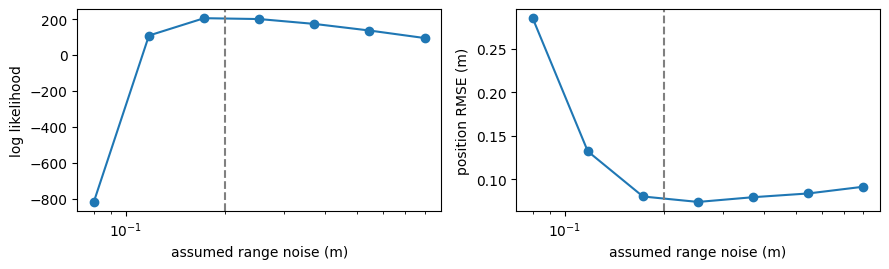

In [9]:
TRUE_ASSUMED = dict(motion_std=TRUE_MOTION, measurement_std=None)
assumed = np.geomspace(0.08, 0.8, 7)

scores, errs = [], []
for value in assumed:
    runs = [particle_filter(*w, 1000, trigger="ESS < 0.5 N", start="known", seed=s,
                            motion_std=TRUE_MOTION, measurement_std=(value, TRUE_MEASUREMENT[1]))
            for s, w in zip(SEEDS, worlds)]
    scores.append(np.mean([r["log_likelihood"] for r in runs]))
    errs.append(np.mean([r["rmse"] for r in runs]))

learned = assumed[int(np.argmax(scores))]
print(f"the world uses {TRUE_MEASUREMENT[0]} m;  learned {learned:.2f} m;  "
      f"set by hand in the reference code: 0.4 m")

fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].plot(assumed, scores, "o-"); ax[0].set_ylabel("log likelihood")
ax[1].plot(assumed, errs, "o-");   ax[1].set_ylabel("position RMSE (m)")
for a in ax:
    a.axvline(TRUE_MEASUREMENT[0], color="grey", ls="--")
    a.set_xscale("log"); a.set_xlabel("assumed range noise (m)")
fig.tight_layout()
plt.show()

The peak sits on the value the world uses, and it was found without ever seeing the robot's true
positions -- only the controls and readings it recorded. The error is lowest at the same place, so on
this problem the most plausible setting is also the most accurate one, and both are closer to the
truth than the 0.4 m set by hand in the reference code.

The curve is one-sided: assuming too little noise is punished far more heavily than assuming too
much, which is why noise values chosen by hand are rationally kept large.